In [2]:
'''
In this file, we will work on implementing the Zermelo problem, with some new changes:
- No obstacles
- The state evolution will be deterministic, as it is when one specifies a flight trajectory
- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity
- Of course, it may be difficult to balance this with the cost associated to reaching the destination
- We will set harsh constraints on the maximum and minimum velocities via a sigmoid
- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet

It will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)
'''

'\nIn this file, we will work on implementing the Zermelo problem, with some new changes:\n- No obstacles\n- The state evolution will be deterministic, as it is when one specifies a flight trajectory\n- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity\n- Of course, it may be difficult to balance this with the cost associated to reaching the destination\n- We will set harsh constraints on the maximum and minimum velocities via a sigmoid\n- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet\n\nIt will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)\n'

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os

In [4]:
# will aim to traverse from (-10, 0) to (10, 0).
# speed of reference trajectories will be 2 units per time step, thus we use time horizon of 10 steps
# will experiment with values for w_min and w_max

def OU_process(x0, sd, theta, mu, sigma, T, time_step):
    total_steps = int(T / time_step)
    process = np.zeros(total_steps + 1, dtype = float)
    process[0] = np.random.normal(loc = x0, scale = sd)
    for t in range(total_steps):
        process[t + 1] = process[t] + theta * (mu - process[t]) * time_step + sigma * np.sqrt(time_step) * np.random.normal()
    return process.astype(np.float32)

def winds(a, b, T, time_step, sigma, theta):
    """
    Simulate OH processes around a and b, then interpolate over the time steps to create an approximate move from a to b over time T, 
    kind of like a wind forecast
    """
    # don't bother with hyperparameters for OU process, just input here
    total_steps = int(T / time_step)
    ou_a = OU_process(a, 0.1, theta, a, sigma, T, time_step)
    ou_b = OU_process(b, 0.1, theta, b, sigma, T, time_step)[::-1]
    interpolants_b = np.linspace(0, 1, total_steps + 1, dtype = np.float32)
    interpolants_a = 1 - interpolants_b
    wind_process = interpolants_a * ou_a + interpolants_b * ou_b
    return wind_process.astype(np.float32)

Text(0.5, 1.0, 'Sample Winds')

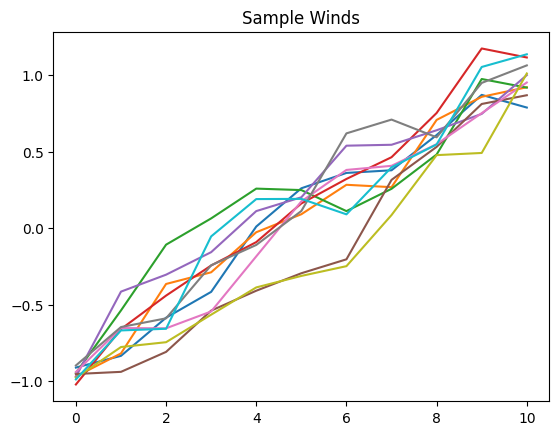

In [5]:
for i in range(10):
    plt.plot(winds(-1, 1, 10, 1, 0.2, 0.1))
plt.title("Sample Winds")

In [6]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [54]:
# define control NNs
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.LeakyReLU()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled

# loss function (wind cost + terminal cost)
def running_loss(wind_value, velocity):
    a = velocity.shape[0]
    b = velocity.shape[1]
    zeros_vecs = torch.zeros((a, b, 1), device = device)
    wind_vector = torch.cat([zeros_vecs, wind_value.view(a, b, 1)], dim  = 2)
    wind_cost = torch.norm(wind_vector - velocity, dim = 2) ** 3
    return wind_cost

def terminal_loss(position, target):
    ones_vec = torch.ones_like(position, device = device)
    target_matrix = ones_vec * target
    final_cost = torch.norm(position - target_matrix, dim = 1) ** 2
    return torch.relu(final_cost - 0.1)

def penalising_velocity(velocity, min_speed, max_speed, multiplier, steepness):
    speed = torch.norm(velocity, dim = 2) # since velocities is 3D tensor
    min_cost = torch.sigmoid(steepness * (min_speed - speed))
    max_cost = torch.sigmoid(steepness * (speed - max_speed))
    return multiplier * torch.relu(min_cost + max_cost - 0.5)

# base policy randomiser function
def random_base_policy(num_policies, num_steps, min_angle, max_angle, base_speed):
    angle_matrix = torch.rand((num_policies, num_steps), device = device) * (max_angle - min_angle) + min_angle
    velocities = torch.stack((torch.cos(angle_matrix), torch.sin(angle_matrix)), dim= -1) * base_speed
    return velocities

In [40]:
# visualise trajectories for a set of random base policies
num_policies = 50
num_steps = 10
policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
target = torch.tensor([-10.0, 0.0], device = device)
base_trajectories = torch.zeros((num_policies, num_steps + 1, 2), device = device)
base_trajectories[:, 0, :] = target
# for t in range(num_steps):
#     base_trajectories[:, t + 1, :] = base_trajectories[:, t, :] + policies[:, t, :]
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
trajectories = torch.cumsum(policies, dim = 1) + torch.tensor([-10, 0], device = device)
trajectories = torch.cat((starts, trajectories), dim = 1)

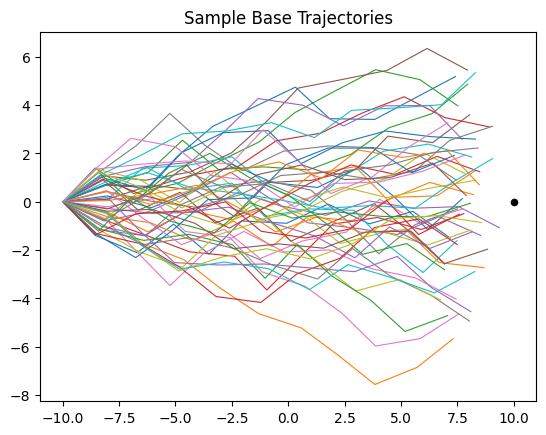

In [41]:
plt.plot(trajectories[:,:,0].cpu().numpy().T, trajectories[:,:,1].cpu().numpy().T, linewidth = 0.8)
plt.title("Sample Base Trajectories")
plt.scatter(10, 0, s = 20, color = "black")
plt.show()

In [43]:
# now, note that our training dataset will be augmented to num_sample * num_policies
def generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta):
    training_data = torch.zeros((n * num_policies, int(T / time_step)), device = device)
    for i in range(n):
        bridge = torch.tensor(winds(a, b, T, time_step, sigma, theta)[: -1], device = device)
        bridge = bridge.repeat(num_policies, 1)
        training_data[i * num_policies : (i + 1) * num_policies, :] = bridge
    return training_data

In [44]:
generate_training_data(-1, 1, 10, 1, 5, 3, 0.2, 0.1)

tensor([[-1.0129, -0.6517, -0.6189, -0.5563, -0.2255, -0.1269,  0.1092,  0.3247,
          0.7260,  0.6302],
        [-1.0129, -0.6517, -0.6189, -0.5563, -0.2255, -0.1269,  0.1092,  0.3247,
          0.7260,  0.6302],
        [-1.0129, -0.6517, -0.6189, -0.5563, -0.2255, -0.1269,  0.1092,  0.3247,
          0.7260,  0.6302],
        [-1.0881, -1.0255, -0.8511, -0.5769, -0.3565, -0.1956,  0.2350,  0.5162,
          0.3490,  0.8912],
        [-1.0881, -1.0255, -0.8511, -0.5769, -0.3565, -0.1956,  0.2350,  0.5162,
          0.3490,  0.8912],
        [-1.0881, -1.0255, -0.8511, -0.5769, -0.3565, -0.1956,  0.2350,  0.5162,
          0.3490,  0.8912],
        [-0.9977, -0.9501, -0.9210, -0.4821, -0.0578, -0.0163,  0.2705,  0.3893,
          0.5303,  0.5746],
        [-0.9977, -0.9501, -0.9210, -0.4821, -0.0578, -0.0163,  0.2705,  0.3893,
          0.5303,  0.5746],
        [-0.9977, -0.9501, -0.9210, -0.4821, -0.0578, -0.0163,  0.2705,  0.3893,
          0.5303,  0.5746],
        [-0.9963, -

In [57]:
# hyperparameters
input_dim = 3
width = 500
output_dim = 2
v_min = 1
v_max = 4
velocity_penalty_multiplier = 50
target_multiplier = 10
n = 20
num_policies = 100
T = 10
time_step = 1
num_steps = int(T / time_step)
base_speed = 2
a = -1
b = 1
start_rate = 0.00001
final_rate = 0.000000001
num_epochs = 2000
target = torch.tensor([10.0, 0.0], device = device)
steepness = 5
sigma = 0.2
theta = 0.1
outer_loops = 3

In [58]:
# generate the training data
training_data = generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta)

# will also need the reference trajectories (same set of num_policies for each sample)
base_policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
ref_paths = torch.cumsum(base_policies, dim = 1) + torch.tensor([-10, 0], device = device)
ref_paths = torch.cat((starts, ref_paths), dim = 1)
# repeat for each instance of the training samples
ref_paths = ref_paths.repeat(n, 1, 1)
# training data and reference paths now fully constructed

In [59]:
# initialise models, optimisers and schedulers
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T)]
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]

In [60]:
for loop in range(outer_loops):
    print(f"Outer loop {loop}")
    for t in reversed(range(T)):
        print(f"t = {t}")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c = 0
            current_paths = [ref_paths[:, t, :]]
            velocities = []
            # generate path from t
            for futs in range(path_length):
                velocity = models_erm[t + futs](torch.cat([current_paths[-1],
                                                        training_data[:, t + futs].view(n * num_policies, 1)], 
                                                        dim = 1))
                current_paths.append(current_paths[-1] + time_step * velocity)
                velocities.append(velocity)
            # stack into 3D tensors
            current_paths = torch.stack(current_paths, dim = 1)
            velocities = torch.stack(velocities, dim = 1)
            # compute losses
            safety_costs = penalising_velocity(velocities, v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs = torch.sum(safety_costs, dim = 1)
            terminal_costs = terminal_loss(current_paths[:, -1, :], target) * 20
            running_losses = running_loss(training_data[:, t:], velocities)
            running_costs = torch.sum(running_losses, dim = 1) / T # kind of normalises
            final_c = final_c + torch.mean(safety_costs + terminal_costs + running_costs)
            # backprop
            final_c.backward()
            optimisers[t].step()
            optimisers[t].zero_grad()
            schedulers[t].step()
            if epoch % 1000 == 0:
                with torch.no_grad():
                    print(f"Epoch {epoch}, Total {final_c:.6f}, Safety {torch.mean(safety_costs):.6f}, Terminal {torch.mean(terminal_costs):.6f}, Running {torch.mean(running_costs):.6f}")
        # freeze model after training
        for param in models_erm[t].parameters():
            param.requires_grad = False
    for model in models_erm:
        for param in model.parameters():
            param.requires_grad = True
    # reset optimisers and schedulers
    optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
    schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]
    # new reference policies are the learned policies for this loop
    ref_paths = current_paths.detach()

Outer loop 0
t = 9
Epoch 0, Total 456.909363, Safety 24.565012, Terminal 432.274475, Running 0.069919
Epoch 1000, Total 27.418871, Safety 8.993270, Terminal 9.716029, Running 8.709570
t = 8
Epoch 0, Total 196.407837, Safety 29.818729, Terminal 160.710373, Running 5.878736
Epoch 1000, Total 15.174269, Safety 0.342964, Terminal 7.990665, Running 6.840639
t = 7
Epoch 0, Total 116.756859, Safety 24.753305, Terminal 86.573143, Running 5.430414
Epoch 1000, Total 8.718552, Safety 0.000000, Terminal 2.035195, Running 6.683356
t = 6
Epoch 0, Total 69.004448, Safety 24.507027, Terminal 37.591949, Running 6.905468
Epoch 1000, Total 6.996002, Safety 0.000000, Terminal 0.125536, Running 6.870466
t = 5
Epoch 0, Total 35.203793, Safety 24.591518, Terminal 1.267349, Running 9.344927
Epoch 1000, Total 7.232784, Safety 0.000000, Terminal 0.053047, Running 7.179736
t = 4
Epoch 0, Total 35.026108, Safety 24.628254, Terminal 0.221149, Running 10.176711
Epoch 1000, Total 7.727538, Safety 0.000000, Terminal 

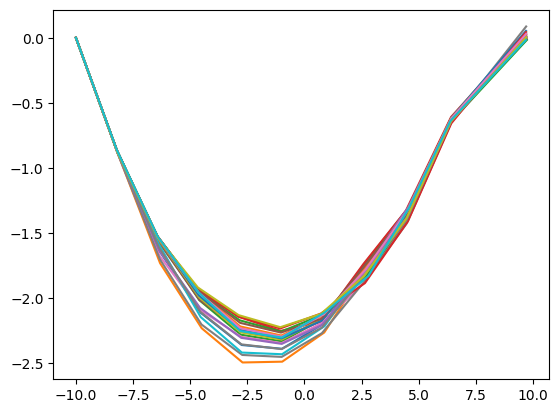

In [61]:
for pth in range(n):
    plt.plot(current_paths[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 1].detach().cpu().numpy())

In [62]:
from ipywidgets import interact, IntSlider

Zs = np.linspace(-2, 2, 20)

# Create grid
xs = np.linspace(-10, 10, 20)
ys = np.linspace(-10, 10, 20)
X, Y = np.meshgrid(xs, ys)

def plot_quiver(model_idx, z_idx):
    model = models_erm[model_idx]
    z = Zs[z_idx]

    # Prepare input for model: shape (N, 3)
    xy = np.stack([X.ravel(), Y.ravel(), np.full_like(X.ravel(), z)], axis=1)
    xy_tensor = torch.tensor(xy, dtype=torch.float32, device = device)

    # Get model output
    with torch.no_grad():
        output = model(xy_tensor).cpu().numpy()

    U = output[:,0].reshape(X.shape)
    V = output[:,1].reshape(X.shape)

    # Plot quiver
    plt.figure(figsize=(10,5))
    plt.quiver(X, Y, U, V)
    plt.title(f"PyTorch Quiver Plot | Model {model_idx+1} | Z = {z}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.grid(True)
    plt.show()

interact(
    plot_quiver,
    model_idx=IntSlider(min=0, max=len(models_erm)-1, step=1, description='Model'),
    z_idx=IntSlider(min=0, max=len(Zs)-1, step=1, description='Z index')
)

interactive(children=(IntSlider(value=0, description='Model', max=9), IntSlider(value=0, description='Z index'…

<function __main__.plot_quiver(model_idx, z_idx)>

tensor(0.0616, device='mps:0', grad_fn=<MaxBackward1>)